# TEMPO quickstart

This notebook follows the OQuPy quickstart setup using `quante.tensornetwork.opensystem` and compares the current `backend="mps"` result with OQuPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from quante.tensornetwork.opensystem.tempo import *

import quante as qt
import quante.tensornetwork.opensystem as qto
from quante.generate.matrix import pauli_matrix

sigma_x = pauli_matrix("X")
sigma_z = pauli_matrix("Z")

up = pauli_matrix("u")
rho0 = up @ up.conj().T

Omega = 1.0
alpha = 0.3
omega_cutoff = 5.0

system = qto.System(0.5 * Omega * sigma_x)
correlation = qto.PowerLawSpectralDensity(alpha=alpha, zeta=1.0, cutoff=omega_cutoff)
bath = qto.Bath(0.5 * sigma_z, correlation)
params = qto.TempoParams(dt=0.1, tcut=3.0, epsrel=1e-4, trunc_cut=1e-8, apply_mpo_method='zip_up',normalize=False)
ts = np.arange(0.0, 15.0 + params.dt / 2, params.dt)

import sys
sys.path.insert(0, "..")

import oqupy
import numpy as np
import matplotlib.pyplot as plt

sigma_x = oqupy.operators.sigma("x")
sigma_y = oqupy.operators.sigma("y")
sigma_z = oqupy.operators.sigma("z")
up_density_matrix = oqupy.operators.spin_dm("z+")
down_density_matrix = oqupy.operators.spin_dm("z-")

Omega = 1.0
omega_cutoff = 5.0
alpha = 0.3

oqupy_system = oqupy.System(0.5 * Omega * sigma_x)
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential')
oqupy_bath = oqupy.Bath(0.5 * sigma_z, correlations)
tempo_parameters = oqupy.TempoParameters(dt=0.1, tcut=3.0, epsrel=10**(-4))

100.0%  101 of 101  [########################################] 00:01<00:00, 79.96it/s 


--> TEMPO computation:
100.0%  100 of  100 [########################################] 00:00:02
Elapsed time: 2.7s


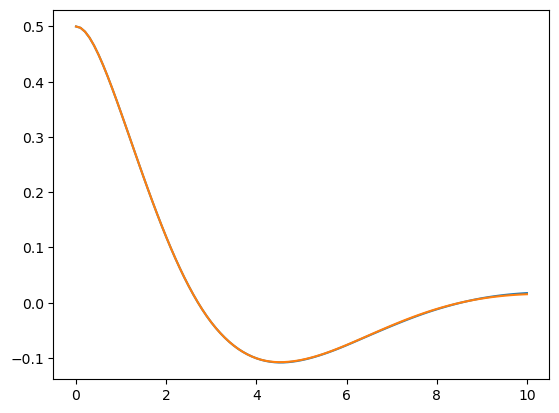

In [2]:
tempo_engine = qto.TempoEngine(system,bath,params,rho0,ts,)
l = 100
res = []
for i in qt.basicfun.tqdm(range(l+1)):
    tempo_engine.run()
    rho = tempo_engine.density_matrix()
    res.append(qt.measure.expect(0.5*sigma_z, rho, isdm=True))
# plt.plot(ts[:l+1], np.real(res))

dt = 0.1
dynamics = oqupy.tempo_compute(system=oqupy_system,
                               bath=oqupy_bath,
                               initial_state=up_density_matrix,
                               start_time=0.0,
                               end_time=dt*l,
                               parameters=tempo_parameters,
                               unique=False)

t, s_z = dynamics.expectations(0.5*sigma_z, real=True)
plt.plot(t, np.real(res))
plt.plot(t, np.real(s_z))

In [669]:
def view_next_adt(tempo_engine, tempo):
    tempo_engine.update_mps(dt)
    print(tempo_engine.mps)   
    step, state = tempo._backend_instance.compute_step()
    tt2 = [node.get_tensor() for node in tempo._backend_instance._mps.nodes]
    tt2[0] = tt2[0].reshape(1,4,4)
    tt2[-1] = tt2[-1].reshape(4,4,1)
    tt2 = MPS(tt2)
    print(tt2)
    ttv = tempo_engine.mps.to_matrix()
    ttv2 = tt2.to_matrix()
    print(ttv)
    print(ttv2)

def view_adt(mps, t=""):
    a,b,c = mps.data[-1].shape
    # print([i.shape for i in mps.data])
    mps.data[-1] = mps.data[-1].reshape(a,-1,1)
    res = mps.to_matrix()
    print(t, res)
    return res

def view_nodes(mps, t=''):
    tensors = []
    for i, node in enumerate(mps.nodes):
        edges = []
        if i == 0:
            if mps.left:
                edges.append(mps.left_edge)
        else:
            edges.append(mps.bond_edges[i-1])
        edges.extend(mps.array_edges[i])

        if i == len(mps) - 1:
            if mps.right:
                edges.append(mps.right_edge)
        else:
            edges.append(mps.bond_edges[i])
        node.reorder_edges(edges)
        tensors.append(node.get_tensor())
        
    mps_tensors = [node.get_tensor() for node in mps.nodes]
    # mps_tensors = tensors
    # print([i.shape for i in mps_tensors])
    if mps_tensors[-1].ndim == 3:
        a, b, c = mps_tensors[-1].shape
        mps_tensors[-1] = mps_tensors[-1].reshape(a,-1,1)
    # print([i.shape for i in mps_tensors])
    res = MPS(mps_tensors).to_matrix()
    print(t, res)
    return res


In [670]:
from numpy import ndarray
from oqupy.backends import node_array as na
from oqupy.util import create_delta

def compute_system_step(self, current_step, prop_1, prop_2) -> ndarray:
    prop_1_na = na.NodeArray([prop_1.T],
                                left=False,
                                right=False,
                                name="first half-step")
    prop_2_na = na.NodeArray([prop_2.T],
                                left=True,
                                right=False,
                                name="second half-step")

    if self._dkmax is None:
        mpo = self._mpo.copy()
        infl = self._influence(len(mpo))
        infl_four_legs = create_delta(infl, [1, 0, 0, 1])
        infl_na = na.NodeArray([infl_four_legs],
                                left=True,
                                right=True)
        self._mpo = na.join(infl_na,
                            self._mpo,
                            name="The Time Evolving MPO",
                            copy=False)
    elif current_step <= self._dkmax:
        _, mpo = na.split(self._mpo,
                            int(0 - current_step),
                            copy=True)
    else:  # current_step > self._dkmax
        mpo = self._mpo.copy()
        infl = self._influence(self._dkmax - current_step)
        if infl is not None:
            infl_four_legs = create_delta(infl, [1, 0, 0, 1])
            infl_na = na.NodeArray([infl_four_legs],
                                    left=True,
                                    right=True)
            _, mpo = na.split(self._mpo,
                                index=1,
                                copy=True)
            mpo = na.join(infl_na,
                            mpo,
                            name="Thee Time Evolving MPO",
                            copy=False)

    mpo.name = "temporary MPO"
    mpo.apply_vector(self._sum_west, left=True)

    self._mps.zip_up(prop_1_na,
                        axes=[(0, 0)],
                        left_index=-1,
                        right_index=-1,
                        direction="left",
                        max_singular_values=None,
                        max_truncation_err=self._epsrel,
                        relative=True,
                        copy=False)

    if len(self._mps) != len(mpo):
        self._mps.contract(self._sum_north_na,
                            axes=[(0, 0)],
                            left_index=0,
                            right_index=0,
                            direction="right",
                            copy=True)
    # view_nodes(self._mps, t="before apply mpo")
    self._mps.zip_up(mpo,
                        axes=[(0, 0)],
                        left_index=0,
                        right_index=-1,
                        direction="right",
                        max_singular_values=None,
                        max_truncation_err=self._epsrel,
                        relative=True,
                        copy=False)

    self._mps.svd_sweep(from_index=-1,
                        to_index=0,
                        max_singular_values=None,
                        max_truncation_err=self._epsrel,
                        relative=True)

    # view_nodes(self._mps, t="after apply mpo")
    # return mpo
    self._mps = na.join(self._mps,
                        prop_2_na,
                        copy=False,
                        name=f"The MPS ({current_step})")

    tmp_mps = self._mps.copy()
    for _ in range(len(tmp_mps) - 1):
        tmp_mps.contract(self._sum_north_na,
                            axes=[(0, 0)],
                            left_index=0,
                            right_index=0,
                            direction="right",
                            copy=True)

    assert len(tmp_mps) == 1
    assert not tmp_mps.left
    assert not tmp_mps.right
    assert tmp_mps.rank == 1
    state = tmp_mps.nodes[0].get_tensor()

    return state


In [671]:
def update_mps(self, dt: float):
    """Update the MPS by applying the TEMPO evolution.
    
            |      |      |      |      |
            ◻——————◻——————◻——————◻——————◻
            |      |      |      |   
            |      |      |      ◻   
            |      |      |      |   
            ◻——————◻——————◻——————◻
    """
    prop_1, prop_2 = self.system.get_propagators(dt)
    if self.cur_layer <= self.params.dkmax:
        mpo = MPO(self.mpo.data[-self.cur_layer-1:])
    else:
        mpo = self.mpo.copy()
        infl = self._influence(self.params.dkmax - self.cur_layer)
        if infl is not None:
            infl_tensor = create_delta(infl, [1, 0, 0, 1])
            mpo.data.append(infl_tensor)
            mpo.data.pop(0)
    sum_west_(mpo)

    self.mps.apply_gate_(self.mps.L-1, gate=prop_1, gate_range=1)
    mps_temp = self.mps.copy()
    
    if self.mps.L > mpo.L:
        sum_north_(self.mps, self.mps.L - mpo.L)
    assert mpo.L == self.mps.L

    trunc_para = (
        self.params.chi_max,
        self.params.svd_min,
        self.params.trunc_cut,
    )
    nm = self.params.normalize
    a,b,c,d = mpo.data[-1].shape
    mpo.data[-1] = mpo.data[-1].swapaxes(2,3).reshape(a,-1,c,1)
    
    # view_adt(self.mps, t="before apply mpo")
    if self.params.apply_mpo_method == 'naive':
        self.mps.apply_mpo_naive_(mpo)
        self.mps.canonicalize_(trunc_para=trunc_para, canonicalform=False, qrnormalize=nm)
    elif self.params.apply_mpo_method == 'density_matrix':
        self.mps.apply_mpo_(mpo, trunc_para=trunc_para, normalize=nm)
    elif self.params.apply_mpo_method == 'zip_up':
        self.mps.apply_mpo_zip_up(mpo, trunc_para=trunc_para, direction="right", normalize=nm)
        self.mps.data, self.mps.Ss, _ = top._right2left_SVD(self.mps.data,self.mps.L,trunc_para=trunc_para)
        self.mps.Ss[0] = self.mps.Ss[-1] = np.array([1.], dtype=self.mps.dtype)
        self.mps.llim = self.mps.rlim = 0
    else:
        raise ValueError(f"apply_mpo_method {self.params.apply_mpo_method!r} is not supported")

    # view_adt(self.mps, t="after apply mpo")
    # return mps_temp, mpo
    # return self.mps
    self.mps.data[-1] = self.mps.data[-1].reshape(-1, b, d)
    a, b = prop_2.shape
    append_mps_(self.mps, prop_2.T.reshape(b,a,1))


In [ ]:

tempo_engine = qto.TempoEngine(system,bath,params,rho0,ts,)
l = 10
for i in range(l+1):
    tempo_engine.run()
# print(tempo_engine.get_rho())

tempo_engine = qto.TempoEngine(system,bath,params,rho0,ts,)
for i in range(1,l+1):
    dt = tempo_engine.dts[i]
    tempo_engine.update_mps(dt)
    tempo_engine.cur_layer += 1
# print(tempo_engine.get_rhso())

tempo = oqupy.Tempo(system=oqupy_system,bath=oqupy_bath,parameters=tempo_parameters,
                  initial_state=up_density_matrix,start_time=0.0,unique=False,)
step, state = tempo._backend_instance.initialize()
tempo._init_dynamics()
for i in range(l):
    step, state = tempo._backend_instance.compute_step()
# print(state.reshape(2,2))


print("quante")
update_mps(tempo_engine, dt)
v1 = view_adt(tempo_engine.mps)

print()
print("oqupy")
backend = tempo._backend_instance
backend._step += 1
prop_1, prop_2 = backend._propagators(backend._step - 1)
state = compute_system_step(backend, backend._step, prop_1, prop_2)
v2 = view_nodes(backend._mps)

np.linalg.norm(v1 - v2)

quante
 [ 0.97408126+0.j         -0.        +0.02435711j  0.        -0.02435711j ...  0.        -0.00001523j -0.        +0.00001523j  0.00060898+0.j        ]

oqupy
 [ 0.97408082-0.j          0.        +0.0243571j  -0.        -0.0243571j  ... -0.        -0.00001493j  0.        +0.00001493j  0.00059698-0.j        ]


0.0004628633362638269

In [632]:
tt2 = [node.get_tensor() for node in mpo2.nodes]
[i.shape for i in tt2]
print(np.linalg.norm(tt2[1] - mpo1.data[1].reshape(4,4,4,4)))
res = mpo1.to_matrix() @ mps1.to_matrix()
print(res)


1.899497856515631e-11
[ 0.99687877+0.j          0.        +0.j          0.        +0.j          0.        +0.j          0.        +0.j         -0.00396736+0.04648636j  0.        +0.j          0.        +0.j          0.        +0.j          0.        +0.j         -0.00396736-0.04648636j  0.        +0.j          0.        +0.j          0.        +0.j          0.        +0.j          0.00249636+0.j         -0.00116663+0.j          0.        +0.j          0.        +0.j          0.        +0.j          0.        +0.j          0.        +0.02024715j  0.        +0.j          0.        +0.j          0.        +0.j          0.        +0.j          0.        +0.0000588j   0.        +0.j          0.        +0.j          0.        +0.j          0.        +0.j          0.00116663+0.j         -0.00116663+0.j          0.        +0.j          0.        +0.j          0.        +0.j          0.        +0.j          0.        -0.0000588j   0.        +0.j          0.        +0.j          0.        +0.j  